# 🏛️ Museu Nacional - Embeddings CLIP das Coleções

Este notebook demonstra o uso dos embeddings visuais e textuais gerados com **CLIP (OpenAI `openai/clip-vit-base-patch32`)** para os objetos da coleção `MN_003`.

### Estrutura dos Arquivos:
- Diretório dos Embeddings: `CLIP/Embeddings_CLIP_MN_003/<codigo_acervo>/`
  - `<nome_imagem>.npy`: Vetor de embedding da imagem (512 dimensões, normalizado em L2).
  - `descricao_embedding.npy`: Vetor de embedding da descrição textual do objeto (512 dimensões, normalizado em L2).
  - `metadata.json`: Informações detalhadas do objeto, metadados e mapeamento dos arquivos.
- `indice_objetos.json`: Índice global com todos os 35 objetos catalogados.
- Imagens Originais: `Base Museu Nacional/MN_003/`


In [7]:
import json
from pathlib import Path
import numpy as np
import torch
from transformers import CLIPProcessor, CLIPModel
from IPython.display import display, Markdown, Image as IPImage

# Resolução automática dos caminhos (funciona tanto na pasta CLIP/ quanto na raiz do projeto)
CURRENT_DIR = Path.cwd().resolve()
if CURRENT_DIR.name == 'CLIP':
    PROJECT_ROOT = CURRENT_DIR.parent
    EMB_DIR = CURRENT_DIR / 'Embeddings_CLIP_MN_003'
else:
    PROJECT_ROOT = CURRENT_DIR
    EMB_DIR = CURRENT_DIR / 'CLIP' / 'Embeddings_CLIP_MN_003'

IMG_DIR = PROJECT_ROOT / 'Base Museu Nacional' / 'MN_003'
INDEX_FILE = EMB_DIR / 'indice_objetos.json'

print(f'Raiz do Projeto:  {PROJECT_ROOT}')
print(f'Pasta de Imagens: {IMG_DIR} (Existe: {IMG_DIR.exists()})')
print(f'Pasta Embeddings: {EMB_DIR} (Existe: {EMB_DIR.exists()})')
print(f'Arquivo de Índice: {INDEX_FILE} (Existe: {INDEX_FILE.exists()})')


Raiz do Projeto:  /home/lucas/Projetos/mn
Pasta de Imagens: /home/lucas/Projetos/mn/Base Museu Nacional/MN_003 (Existe: True)
Pasta Embeddings: /home/lucas/Projetos/mn/CLIP/Embeddings_CLIP_MN_003 (Existe: True)
Arquivo de Índice: /home/lucas/Projetos/mn/CLIP/Embeddings_CLIP_MN_003/indice_objetos.json (Existe: True)


### 1. Carregar Índice e Listar Objetos Processados

In [8]:
with open(INDEX_FILE, "r", encoding="utf-8") as f:
    index_data = json.load(f)

print(f"Modelo: {index_data.get('modelo_clip')}")
print(f"Total de objetos indexados: {index_data.get('total_objetos')}")

# Exibir os 5 primeiros objetos
for obj in index_data["objetos"][:5]:
    print(f"- {obj['codigo_acervo']} ({obj['total_imagens']} imagens): {obj['descricao'][:80]}...")

Modelo: openai/clip-vit-base-patch32
Total de objetos indexados: 35
- MNSEE.003.0012 (2 imagens): Maracá/ Mbaraká. Instrumento musical e ritualístico. Artesã Micaela Vargas. Alde...
- MNSEE.003.0001 (5 imagens): Peneira/ Yrupẽ. A peneira possui uma separação em cruz no centro, ela ajuda na d...
- MNSEE.003.0002 (3 imagens): Abanador/Tepeká feito com fibras vegetais trançadas. Artesã Micaela Vargas, Alde...
- MNSEE.003.0003 (3 imagens): Borduna/Yvyra. Arma contundente feita de madeira dura usada para bordoar. Artesã...
- MNSEE.003.0004 (2 imagens): Borduna/Tamangá Poxi. Talhado em secção, instrumento de ataque usado na retomada...


### 2. Inspeção de um Objeto Específico e seus Vetores

In [9]:
sample_code = "MNSEE.003.0001"  # Exemplo: Peneira / Yrupẽ
obj_dir = EMB_DIR / sample_code

with open(obj_dir / "metadata.json", "r", encoding="utf-8") as f:
    meta = json.load(f)

print(f"Código: {meta['codigo_acervo']}")
print(f"Coleção: {meta['titulo_colecao']}")
print(f"Descrição: {meta['descricao']}")
print(f"Imagens associadas: {len(meta['imagens'])}")

text_emb = np.load(obj_dir / "descricao_embedding.npy")
print(f"Shape do embedding de texto: {text_emb.shape}, Norma L2: {np.linalg.norm(text_emb):.4f}")

for img_info in meta["imagens"]:
    emb = np.load(obj_dir / img_info["arquivo_embedding"])
    print(f"  -> {img_info['arquivo_imagem']}: shape {emb.shape}, norma: {np.linalg.norm(emb):.4f}")

Código: MNSEE.003.0001
Coleção: Coleção Guarani Kaiowá - Tekohá em litígio - 2020.
Descrição: Peneira/ Yrupẽ. A peneira possui uma separação em cruz no centro, ela ajuda na delimitação de quadrantes e na divisão entre grãos mais finos. Artesã Micaela Vargas. Aldeia Kurusu-Amba (Jguapiré) -  Mato Grosso do Sul, Brasil. Dimensões: A-16cm; D-45cm. Acervo do Setor de Etnologia e Etnografia, Museu Nacional/UFRJ. Coleção Guarani Kaiowá - Tekohá em litígio, doada em 2020.
Imagens associadas: 5
Shape do embedding de texto: (512,), Norma L2: 1.0000
  -> MN 003-83.jpg: shape (512,), norma: 1.0000
  -> MN 003-84.jpg: shape (512,), norma: 1.0000
  -> MN 003-85.jpg: shape (512,), norma: 1.0000
  -> MN 003-86.jpg: shape (512,), norma: 1.0000
  -> MN 003-87.jpg: shape (512,), norma: 1.0000


### 3. Busca Multimodal por Texto usando CLIP
Como os vetores estão no mesmo espaço semântico e normalizados, o produto escalar é exatamente a similaridade de cosseno!

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 42163.39it/s]


Total de imagens indexadas no banco: 113 com dimensão 512


### 🔍 Resultados para: *'obejto que pode ser usado para matar'*

**1. Objeto `MNSEE.003.0007` - Imagem `MN 003-26.jpg` (Score: 0.2160)**

> *Flecha/ Hu'y.  Foi usada na retomada de 2006 de Itay e Cambiy como arma. Artesão Ricardo (pai do Ezequiel). Aldeia Itay ...*

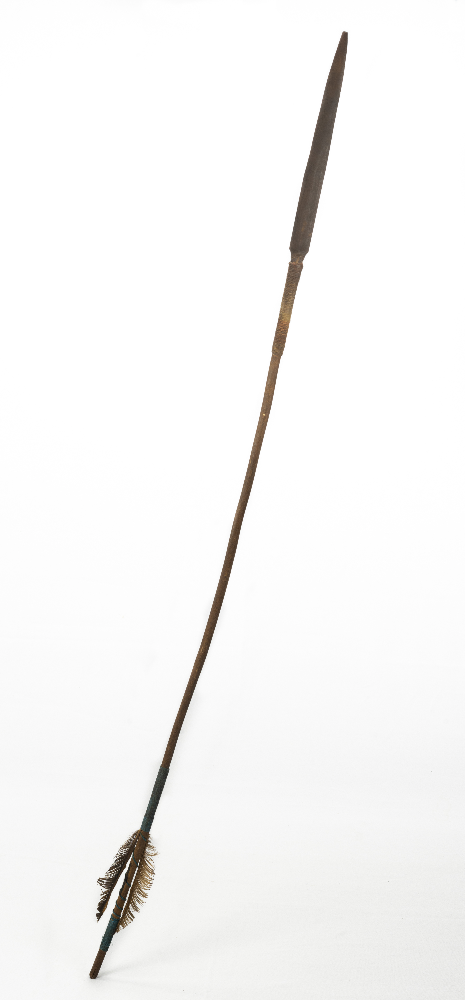

**2. Objeto `MNSEE.003.0007` - Imagem `MN 003-27.jpg` (Score: 0.2156)**

> *Flecha/ Hu'y.  Foi usada na retomada de 2006 de Itay e Cambiy como arma. Artesão Ricardo (pai do Ezequiel). Aldeia Itay ...*

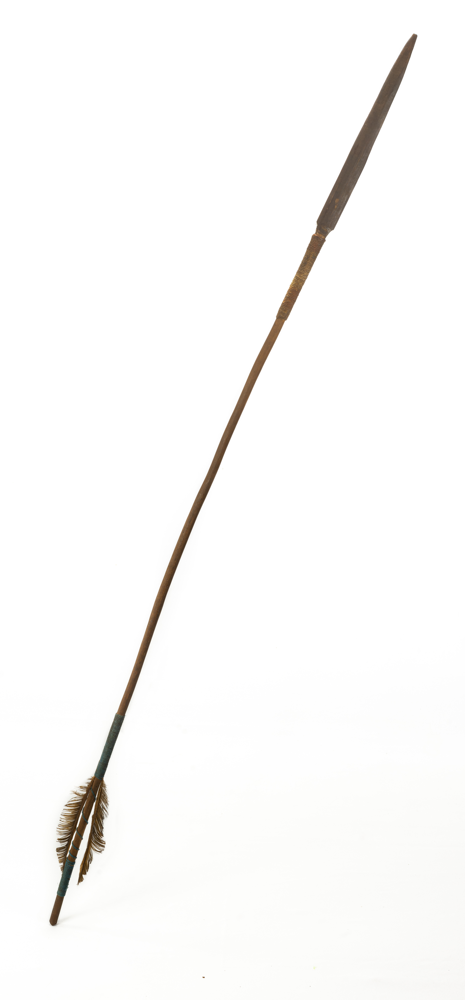

**3. Objeto `MNSEE.003.0005` - Imagem `MN 003-104.jpg` (Score: 0.2071)**

> *Borduna/ Tamangá. Arma contundente feita de madeira dura usada para bordoar. Artesão Maculino Fernandes. Aldeia Kurusu-A...*

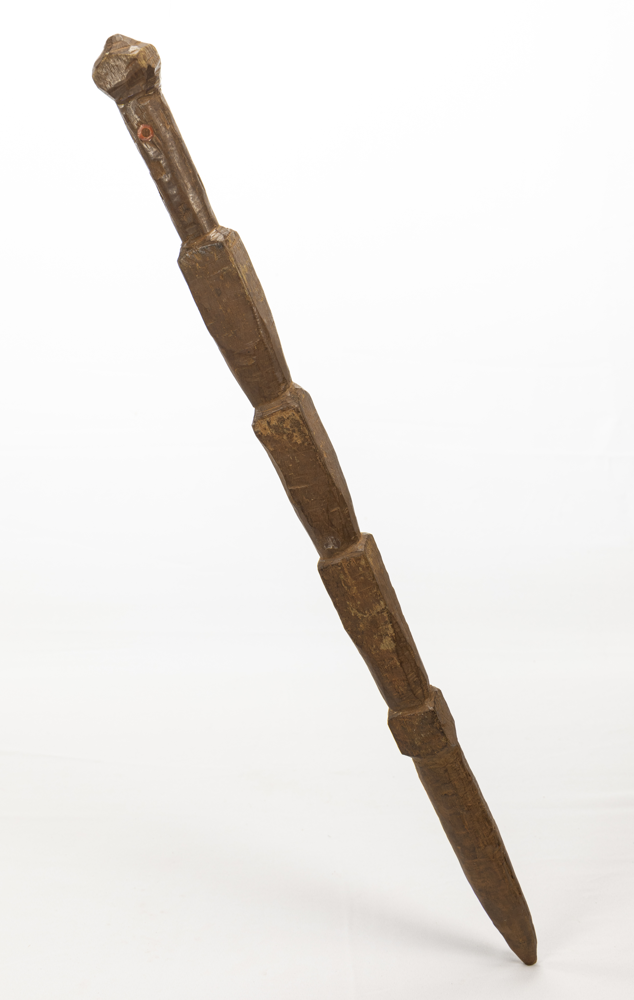

In [10]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = CLIPModel.from_pretrained('openai/clip-vit-base-patch32').to(device)
processor = CLIPProcessor.from_pretrained('openai/clip-vit-base-patch32')
model.eval()

# Carregar todos os embeddings de imagens em memória para busca rápida
all_image_embeddings = []
all_image_records = []

for obj in index_data['objetos']:
    code = obj['codigo_acervo']
    meta_path = EMB_DIR / code / 'metadata.json'
    with open(meta_path, 'r', encoding='utf-8') as f:
        m = json.load(f)
    for img_entry in m['imagens']:
        emb_path = EMB_DIR / code / img_entry['arquivo_embedding']
        emb = np.load(emb_path)
        all_image_embeddings.append(emb)
        all_image_records.append({
            'codigo': code,
            'imagem': img_entry['arquivo_imagem'],
            'descricao': m['descricao']
        })

all_image_embeddings = np.array(all_image_embeddings)
print(f'Total de imagens indexadas no banco: {all_image_embeddings.shape[0]} com dimensão {all_image_embeddings.shape[1]}')

def extract_tensor(features):
    if hasattr(features, 'pooler_output') and features.pooler_output is not None:
        return features.pooler_output
    if hasattr(features, 'text_embeds') and features.text_embeds is not None:
        return features.text_embeds
    if isinstance(features, torch.Tensor):
        return features
    return features

def buscar_por_texto(consulta: str, top_k: int = 3):
    # Gera embedding da consulta de texto
    inputs = processor(text=[consulta], return_tensors='pt', padding=True, truncation=True).to(device)
    with torch.no_grad():
        query_raw = model.get_text_features(**inputs)
        query_features = extract_tensor(query_raw)
        query_features = query_features / query_features.norm(p=2, dim=-1, keepdim=True)
        query_emb = query_features.cpu().numpy().squeeze(0)
    
    # Similaridade de cosseno (dot product de vetores unitários)
    similarities = np.dot(all_image_embeddings, query_emb)
    top_indices = np.argsort(similarities)[::-1][:top_k]
    
    display(Markdown(f"### 🔍 Resultados para: *'{consulta}'*"))
    for rank, idx in enumerate(top_indices, 1):
        rec = all_image_records[idx]
        score = similarities[idx]
        display(Markdown(f"**{rank}. Objeto `{rec['codigo']}` - Imagem `{rec['imagem']}` (Score: {score:.4f})**"))
        display(Markdown(f"> *{rec['descricao'][:120]}...*"))
        display(IPImage(filename=str(IMG_DIR / rec['imagem']), width=300))

# Teste com consulta em linguagem natural
buscar_por_texto('obejto que pode ser usado para matar', top_k=3)
